[*********************100%***********************]  15 of 15 completed
/tmp/ipykernel_3170/2173541629.py:14: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retornos = dados.pct_change().dropna()


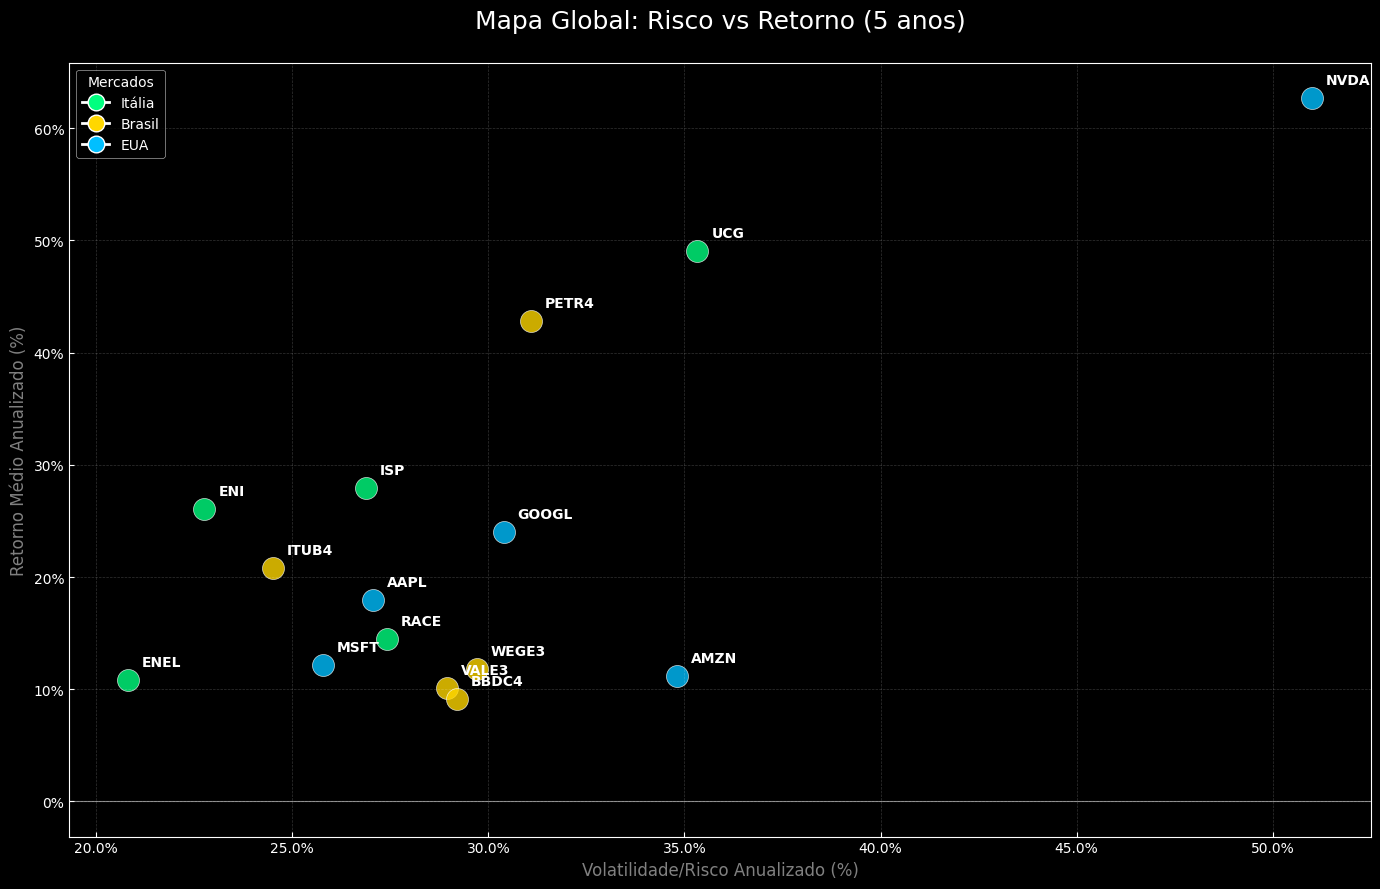

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

italy = ['ENI.MI', 'ENEL.MI', 'ISP.MI', 'RACE.MI', 'UCG.MI']
brazil = ['VALE3.SA', 'PETR4.SA', 'ITUB4.SA', 'BBDC4.SA', 'WEGE3.SA']
usa = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']
todos_ativos = italy + brazil + usa

df = yf.download(todos_ativos, period='5y', auto_adjust=True)
dados = df['Close']
retornos = dados.pct_change().dropna()
retorno_anual = retornos.mean() * 252
volatilidade_anual = retornos.std() * np.sqrt(252)

plt.style.use('dark_background')
plt.figure(figsize=(14, 9))

cores_map = {'Itália': '#00FF7F', 'Brasil': '#FFD700', 'EUA': '#00BFFF'}

for ativo in todos_ativos:
    if ativo in italy: cor = cores_map['Itália']
    elif ativo in brazil: cor = cores_map['Brasil']
    else: cor = cores_map['EUA']

    plt.scatter(volatilidade_anual[ativo], retorno_anual[ativo],
                s=250, color=cor, alpha=0.8, edgecolors='white', linewidth=0.5)

    nome_limpo = ativo.split('.')[0]
    plt.annotate(nome_limpo, (volatilidade_anual[ativo], retorno_anual[ativo]),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=10, fontweight='bold', color='white')

ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.title('Mapa Global: Risco vs Retorno (5 anos)', fontsize=18, pad=25, color='white')
plt.xlabel('Volatilidade/Risco Anualizado (%)', fontsize=12, color='gray')
plt.ylabel('Retorno Médio Anualizado (%)', fontsize=12, color='gray')
plt.grid(True, alpha=0.2, linestyle='--')
plt.axhline(0, color='white', linewidth=0.8, alpha=0.5)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label=p,
                          markerfacecolor=c, markersize=12) for p, c in cores_map.items()]
plt.legend(handles=legend_elements, title="Mercados", loc='upper left', frameon=True)

plt.tight_layout()
plt.show()


[*********************100%***********************]  15 of 15 completed
/tmp/ipykernel_3170/14486414.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retornos = dados.pct_change().dropna()


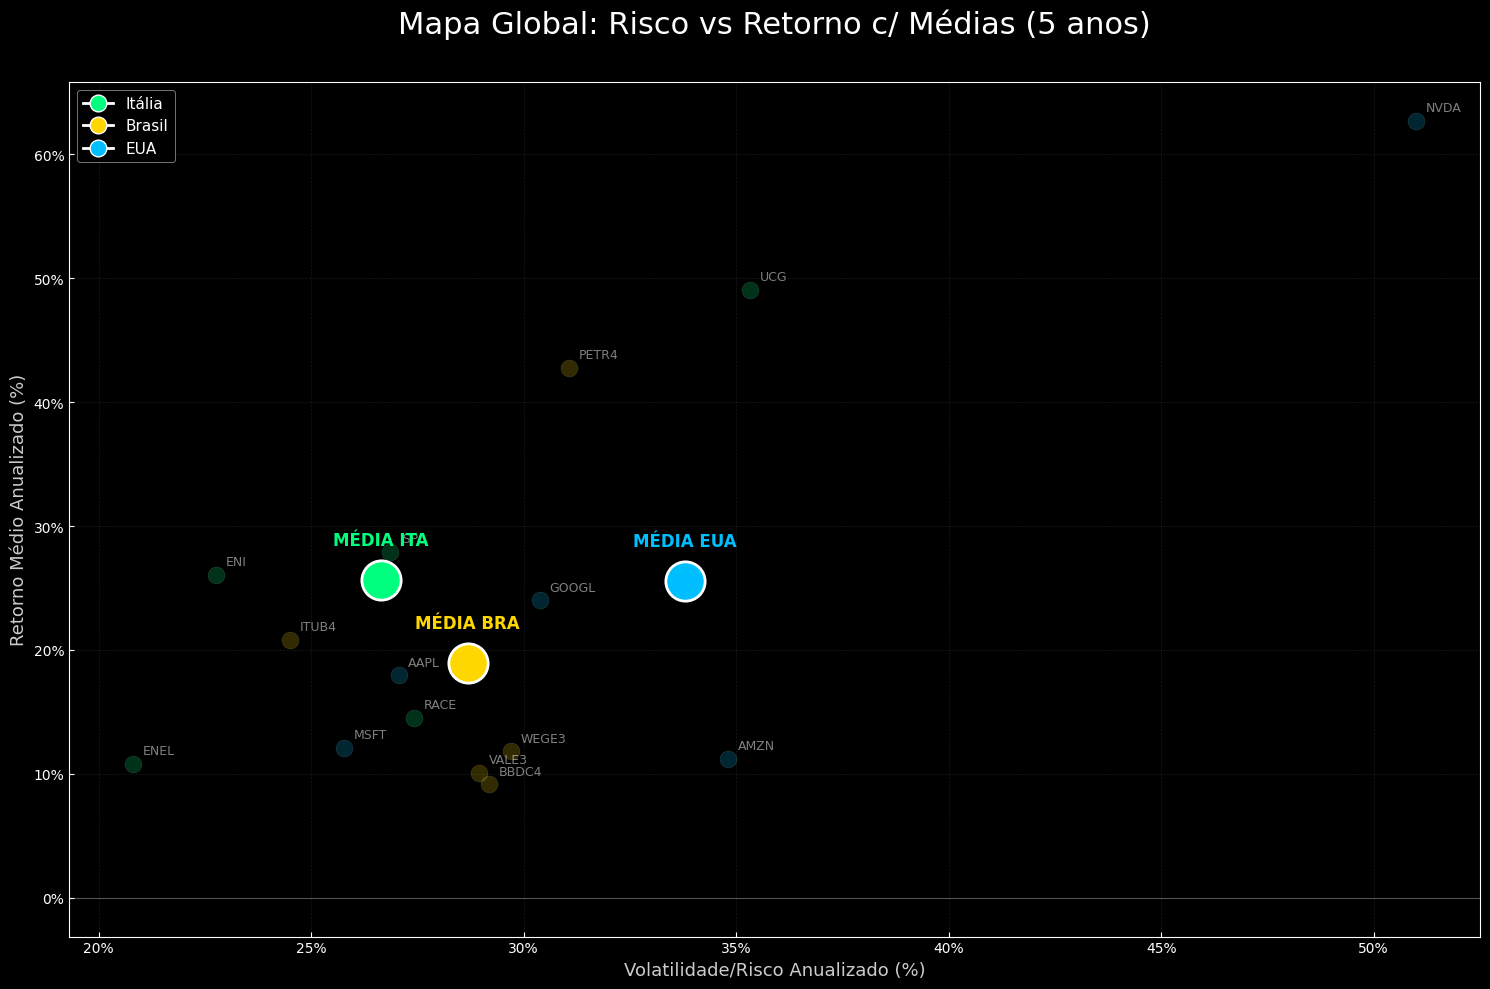

In [ ]:
italy = ['ENI.MI', 'ENEL.MI', 'ISP.MI', 'RACE.MI', 'UCG.MI']
brazil = ['VALE3.SA', 'PETR4.SA', 'ITUB4.SA', 'BBDC4.SA', 'WEGE3.SA']
usa = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']
todos_ativos = italy + brazil + usa

df = yf.download(todos_ativos, period='5y', auto_adjust=True)
dados = df['Close']
retornos = dados.pct_change().dropna()
retorno_anual = retornos.mean() * 252
volatilidade_anual = retornos.std() * np.sqrt(252)

m_ret_ita, m_vol_ita = retorno_anual[italy].mean(), volatilidade_anual[italy].mean()
m_ret_bra, m_vol_bra = retorno_anual[brazil].mean(), volatilidade_anual[brazil].mean()
m_ret_usa, m_vol_usa = retorno_anual[usa].mean(), volatilidade_anual[usa].mean()

plt.style.use('dark_background')
plt.figure(figsize=(15, 10))

cores_map = {'Itália': '#00FF7F', 'Brasil': '#FFD700', 'EUA': '#00BFFF'}

for ativo in todos_ativos:
    cor = cores_map['Itália'] if ativo in italy else cores_map['Brasil'] if ativo in brazil else cores_map['EUA']
    plt.scatter(volatilidade_anual[ativo], retorno_anual[ativo], s=150, color=cor, alpha=0.2, edgecolors='white', linewidth=0.3)
    nome_limpo = ativo.split('.')[0]
    plt.annotate(nome_limpo, (volatilidade_anual[ativo], retorno_anual[ativo]), xytext=(7, 7), textcoords='offset points', fontsize=9, alpha=0.5)

plt.scatter(m_vol_ita, m_ret_ita, s=800, color=cores_map['Itália'], edgecolors='white', linewidth=2)
plt.annotate('MÉDIA ITA', (m_vol_ita, m_ret_ita), xytext=(0, 25), textcoords='offset points', ha='center', fontweight='bold', color=cores_map['Itália'], fontsize=12)

plt.scatter(m_vol_bra, m_ret_bra, s=800, color=cores_map['Brasil'], edgecolors='white', linewidth=2)
plt.annotate('MÉDIA BRA', (m_vol_bra, m_ret_bra), xytext=(0, 25), textcoords='offset points', ha='center', fontweight='bold', color=cores_map['Brasil'], fontsize=12)

plt.scatter(m_vol_usa, m_ret_usa, s=800, color=cores_map['EUA'], edgecolors='white', linewidth=2)
plt.annotate('MÉDIA EUA', (m_vol_usa, m_ret_usa), xytext=(0, 25), textcoords='offset points', ha='center', fontweight='bold', color=cores_map['EUA'], fontsize=12)

ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

plt.title('Mapa Global: Risco vs Retorno c/ Médias (5 anos)', fontsize=22, pad=35)
plt.xlabel('Volatilidade/Risco Anualizado (%)', fontsize=13, color='gray')
plt.ylabel('Retorno Médio Anualizado (%)', fontsize=13, color='gray')
plt.grid(True, alpha=0.1, linestyle='--')
plt.axhline(0, color='white', linewidth=0.8, alpha=0.3)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label=p, markerfacecolor=c, markersize=12) for p, c in cores_map.items()]
plt.legend(handles=legend_elements, loc='upper left', fontsize=11, frameon=True)

plt.tight_layout()
plt.show()